# **INTRODUCTION** 

This project uses Machine Learning and SHAP Explainability to detect potential ESG Greenwashing in Energy, Utilities, and Industrial companies from 2010–2024.

The notebook includes:
- ✔ Exploratory Data Analysis
- ✔ Feature Engineering
- ✔ Random Forest Classification
- ✔ ROC-AUC Evaluation
- ✔ SHAP Explainable AI
- ✔ ESG Risk Insights 

# **1️⃣ Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier

import shap

import warnings
warnings.filterwarnings('ignore')

# **2️⃣ Load Dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/esg-greenwashing-energy-and-industrials/esg_greenwashing_energy_utilities_industrials_2010_2024.csv")

df.head()

,year,company,ticker,sector,country,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified,greenwashing_flag
0,2010,ExxonMobil,XOM,Energy,USA,393.8,119.31,9.45,1123.35,128.76,NaN,0.30,27.7,D,No,No,Yes,Yes,0
1,2011,ExxonMobil,XOM,Energy,USA,390.7,111.91,8.56,976.85,120.47,-6.20,0.29,31.5,C,No,No,No,No,0
2,2012,ExxonMobil,XOM,Energy,USA,373.3,119.87,9.73,1210.04,129.60,7.11,0.32,30.9,C,No,No,No,No,0
3,2013,ExxonMobil,XOM,Energy,USA,396.5,110.06,8.76,1020.99,118.82,-8.18,0.28,32.3,B,No,No,Yes,Yes,0
4,2014,ExxonMobil,XOM,Energy,USA,381.1,115.06,10.49,1021.43,125.55,4.54,0.30,33.1,B-,No,No,No,No,0


# **3️⃣ Dataset Overview**

## **Shape**

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (450, 19)


## **Column Names**

In [4]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['year', 'company', 'ticker', 'sector', 'country', 'revenue_usd_bn',
       'scope1_emissions_mt_co2e', 'scope2_emissions_mt_co2e',
       'scope3_emissions_mt_co2e', 'total_s1_s2_mt_co2e',
       'yoy_scope1_change_pct', 'carbon_intensity_tco2e_per_musd',
       'esg_score_0_100', 'cdp_climate_score', 'net_zero_target_set',
       'sbti_committed', 'emissions_disclosed', 'third_party_verified',
       'greenwashing_flag'],
      dtype='object')


## **Info** 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   year                             450 non-null    int64  
 1   company                          450 non-null    object 
 2   ticker                           450 non-null    object 
 3   sector                           450 non-null    object 
 4   country                          450 non-null    object 
 5   revenue_usd_bn                   450 non-null    float64
 6   scope1_emissions_mt_co2e         450 non-null    float64
 7   scope2_emissions_mt_co2e         450 non-null    float64
 8   scope3_emissions_mt_co2e         450 non-null    float64
 9   total_s1_s2_mt_co2e              450 non-null    float64
 10  yoy_scope1_change_pct            420 non-null    float64
 11  carbon_intensity_tco2e_per_musd  450 non-null    float64
 12  esg_score_0_100       

## **Missing Values**

In [6]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

year                                0
company                             0
ticker                              0
sector                              0
country                             0
revenue_usd_bn                      0
scope1_emissions_mt_co2e            0
scope2_emissions_mt_co2e            0
scope3_emissions_mt_co2e            0
total_s1_s2_mt_co2e                 0
yoy_scope1_change_pct              30
carbon_intensity_tco2e_per_musd     0
esg_score_0_100                     0
cdp_climate_score                   0
net_zero_target_set                 0
sbti_committed                      0
emissions_disclosed                 0
third_party_verified                0
greenwashing_flag                   0
dtype: int64


# **4️⃣ Exploratory Data Analysis (EDA) 📊**

## **Target Distribution** 

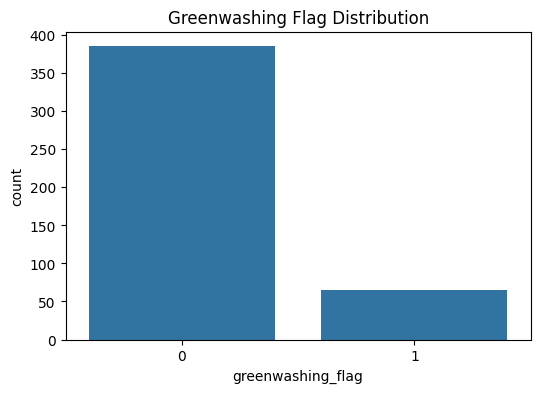

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='greenwashing_flag', data=df)

plt.title("Greenwashing Flag Distribution")
plt.show()

## **ESG Score Distribution**

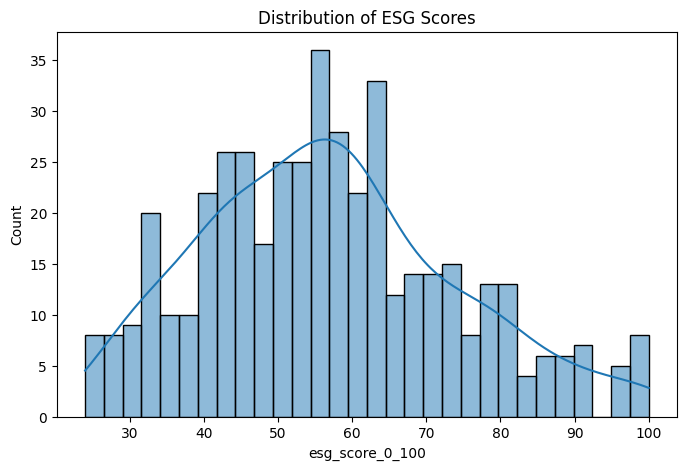

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['esg_score_0_100'], bins=30, kde=True)

plt.title("Distribution of ESG Scores")
plt.show()

## **Correlation Heatmap**

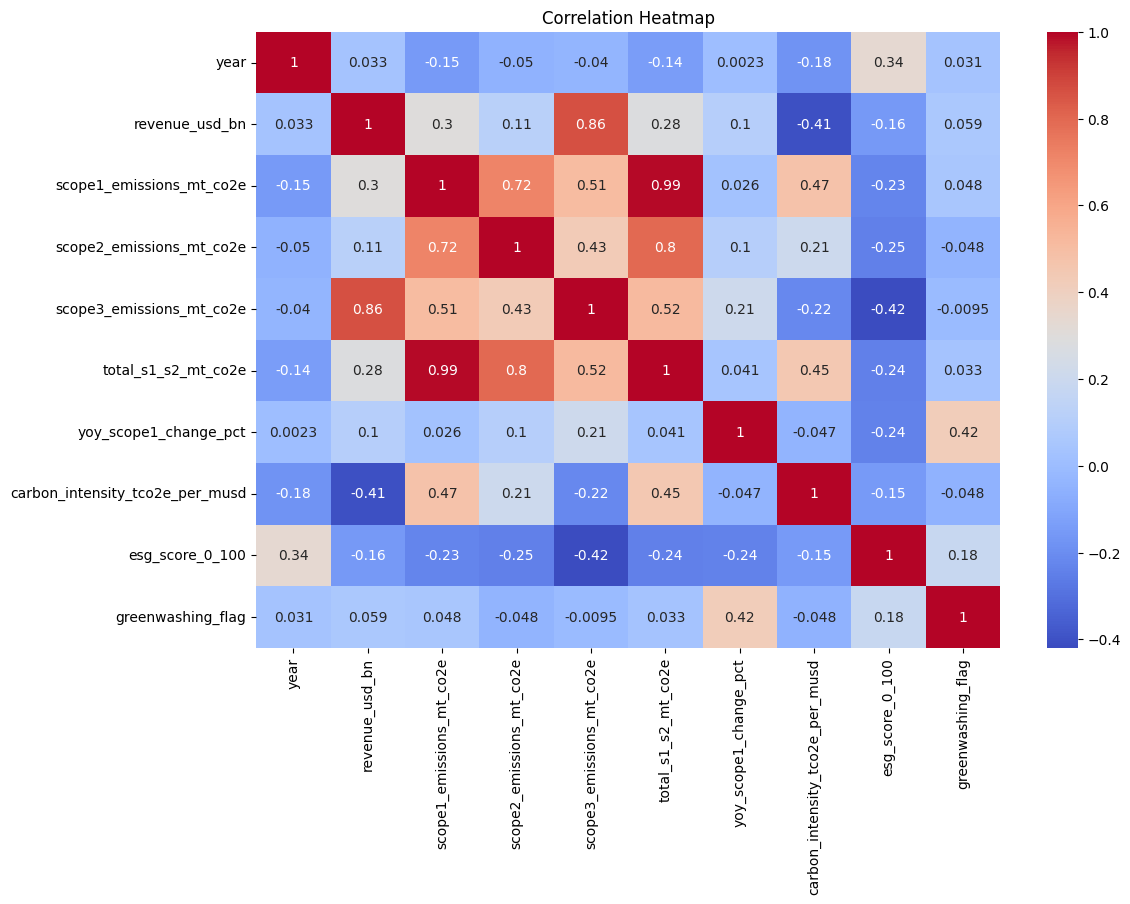

In [9]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## **Sector-wise Greenwashing** 

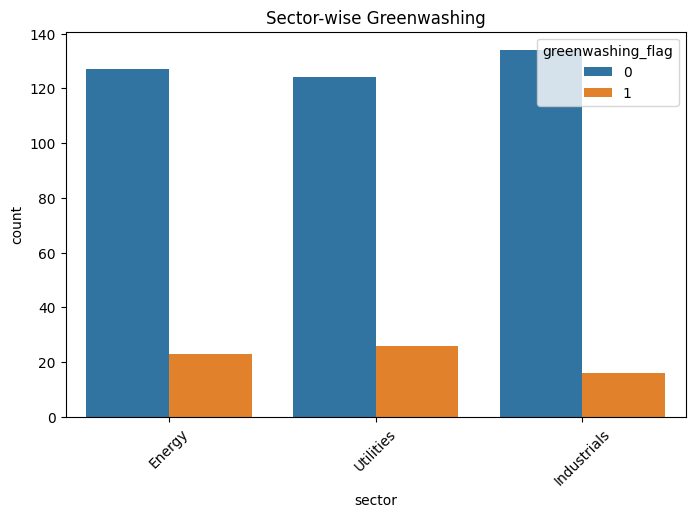

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='sector',
    hue='greenwashing_flag',
    data=df
)

plt.title("Sector-wise Greenwashing")
plt.xticks(rotation=45)
plt.show()

# **5️⃣ Data Preprocessing ⚙️**

## **Copy Dataset** 

In [11]:
data = df.copy()

## **Fill Missing Values** 

In [12]:
data.fillna(data.median(numeric_only=True), inplace=True)

## **Encode Categorical Columns** 

In [13]:
categorical_cols = data.select_dtypes(include='object').columns
encoder = LabelEncoder()

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])


## **Features & Target** 

In [14]:
X = data.drop('greenwashing_flag', axis=1)
y = data['greenwashing_flag']

## **Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (360, 18)
Testing Shape: (90, 18)


# **6️⃣ Build Machine Learning Model 🤖**

## **Random Forest Model** 

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

In [17]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# **7️⃣ Model Evaluation 📈**

## **Accuracy** 

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 100.0 %


## **Classification Report** 

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        77
           1       1.00      1.00      1.00        13

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



## **Confusion Matrix**

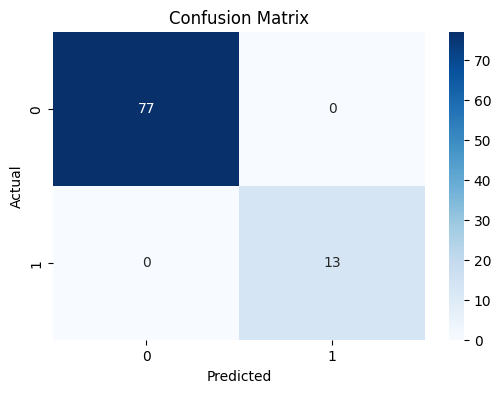

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **ROC Curve 🔥**

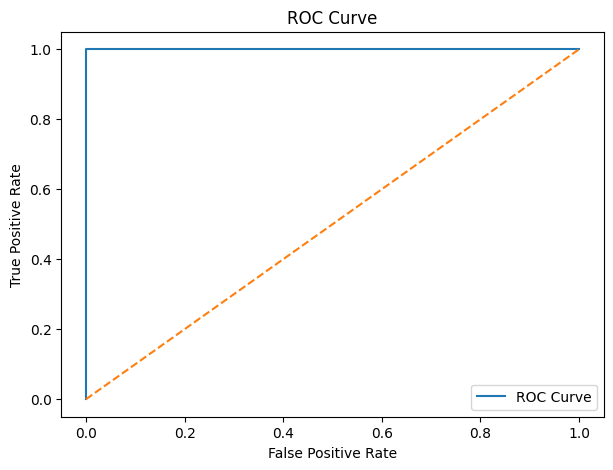

ROC-AUC Score: 1.0


In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_score,3))

# **8️⃣ Feature Importance 🌟**

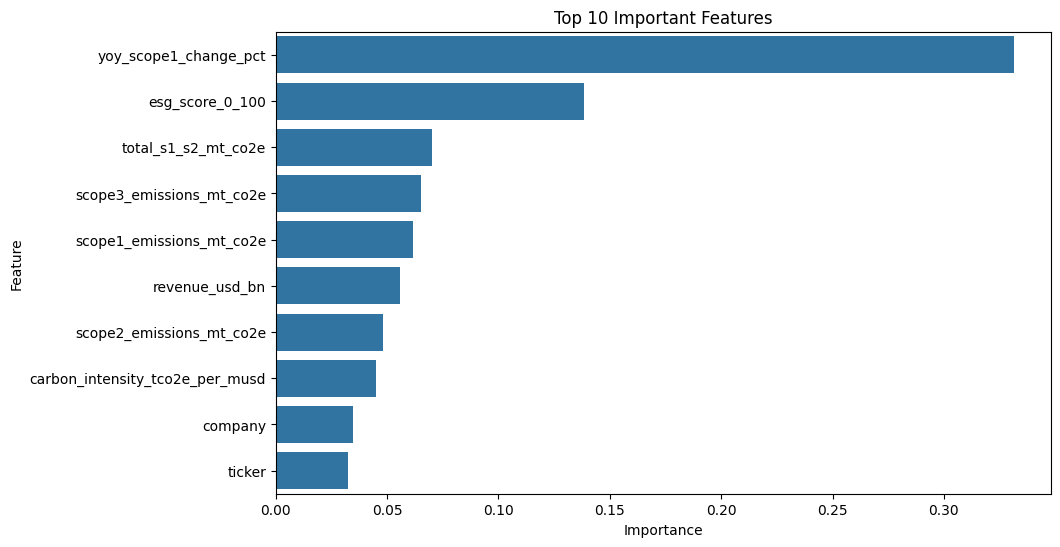

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# **9️⃣ Explainable AI using SHAP 🧠🔥**

<Figure size 1440x840 with 0 Axes>

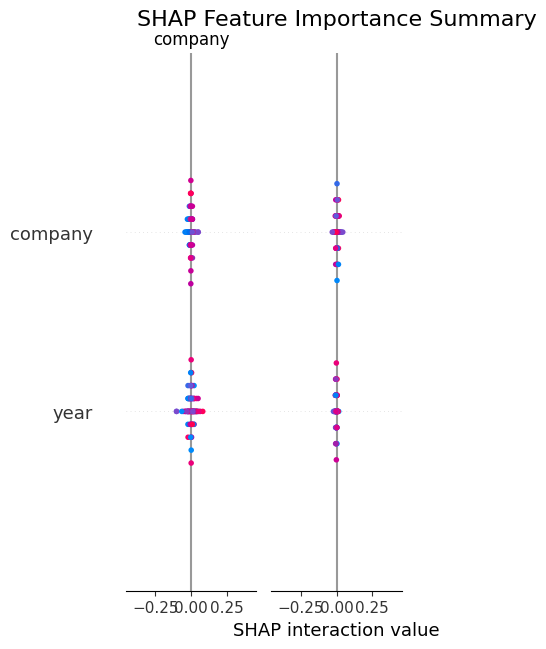

In [23]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_test,
    check_additivity=False
)

plt.figure(figsize=(12, 7), dpi=120)

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_test,
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

plt.title(
    "SHAP Feature Importance Summary",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# **🔟 Prediction Example**

In [24]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("⚠️ Potential Greenwashing Detected")
else:
    print("✅ No Greenwashing Detected")

✅ No Greenwashing Detected


# **1️⃣1️⃣ Final Insights 📌**

In [25]:
print("""
Key Insights:

1. ESG-related metrics strongly influence greenwashing prediction.
2. Emission disclosure and third-party verification are critical indicators.
3. SHAP explainability helps identify why companies are flagged.
4. Machine Learning can support ESG transparency and sustainability analysis.
""")


Key Insights:

1. ESG-related metrics strongly influence greenwashing prediction.
2. Emission disclosure and third-party verification are critical indicators.
3. SHAP explainability helps identify why companies are flagged.
4. Machine Learning can support ESG transparency and sustainability analysis.

